# Oncologics Dataset - SYNCO Results and Plots

This notebook demonstrates all SYNCO plotting capabilities using the Oncologics dataset, including:
- Performance rings (cell line and inhibitor combination)
- Classification plots
- Distribution plots
- ROC/PR curves with confidence intervals and threshold sweeps
- Profile category analysis

**Usage**:
1. Edit the `run_date` variable below to select your dataset
2. Run cells sequentially to generate all plots
3. All plots are saved to the `plots/` directory within your results folder

## Setup and Configuration

In [1]:
from pathlib import Path
import pandas as pd
import plotly.graph_objects as go

# Import SYNCO plotting modules
from synco.plotting.performance import make_performance_plots, make_ring_plots
from synco.plotting.classification import make_classification_plots
from synco.plotting.pred_distributions import make_pred_distribution_plots
from synco.plotting.exp_distributions import make_experimental_distribution_plots
from synco.plotting.profile_categories import make_profilecat_plots
from synco.plotting.roc_plots import make_roc_plots

In [9]:
# Configure paths for Oncologics dataset
run_date = '20251013'  # Change to '20250804' or your custom date

BASE = Path('oncologics') / run_date
results_dir = BASE / 'synco_output'
plots_dir = BASE / 'plots'
show = True  # Display interactive plots inline

print(f'Results directory: {results_dir}')
print(f'Plots directory: {plots_dir}')
print(f'Results exist: {results_dir.exists()}')

# Create plots directory
plots_dir.mkdir(parents=True, exist_ok=True)

Results directory: oncologics\20251013\synco_output
Plots directory: oncologics\20251013\plots
Results exist: True


## 1. Performance Ring Plots

Ring plots visualize model performance showing:
- **Outer ring**: Match (blue) vs Mismatch (orange)
- **Inner ring**: True Positives, True Negatives, False Positives, False Negatives
- **Center**: Recall percentage

### Aggregate Performance Ring

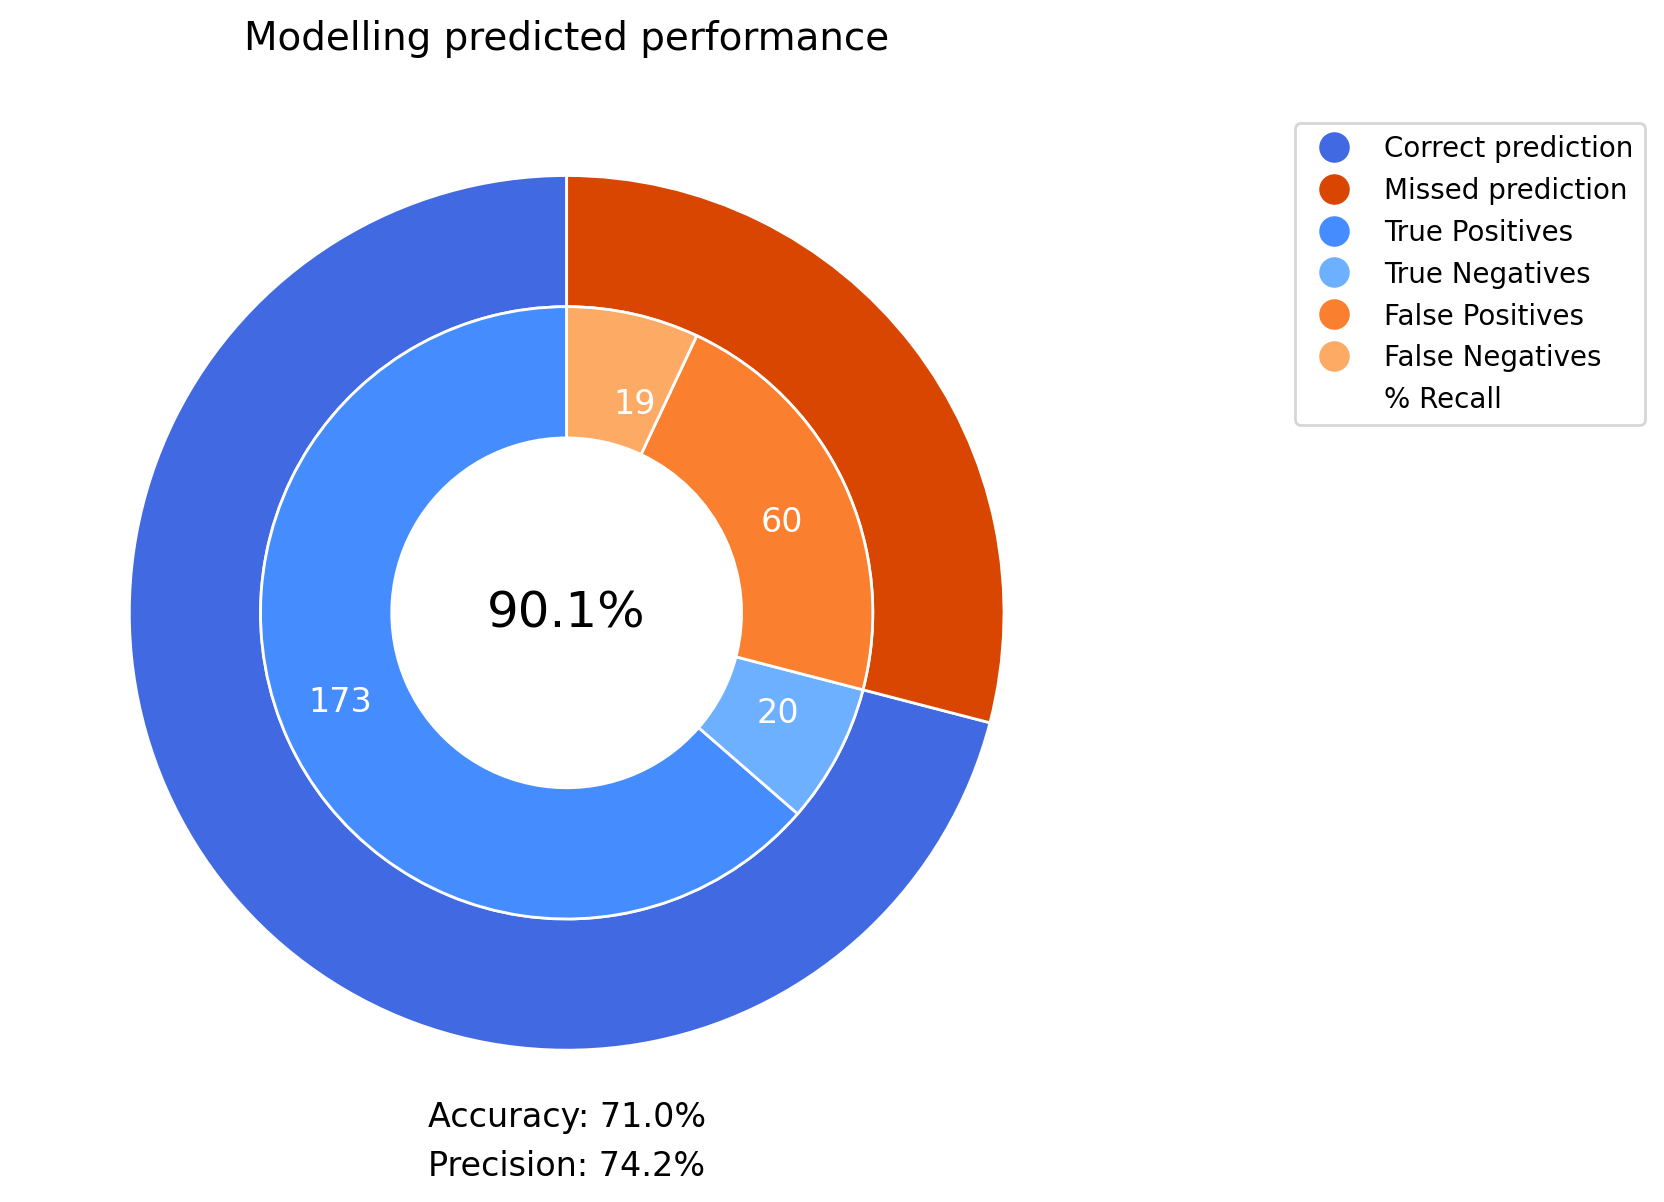

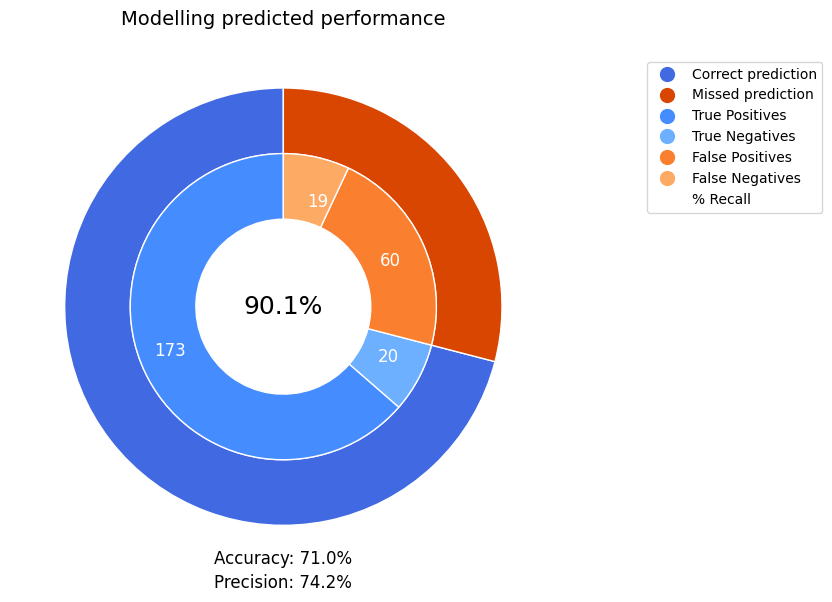

In [10]:
# Single aggregate ring showing overall performance
make_performance_plots(
    str(results_dir), 
    plots_dir=str(plots_dir), 
    show=show, 
    performance='ring'
)

### Performance by Cell Line

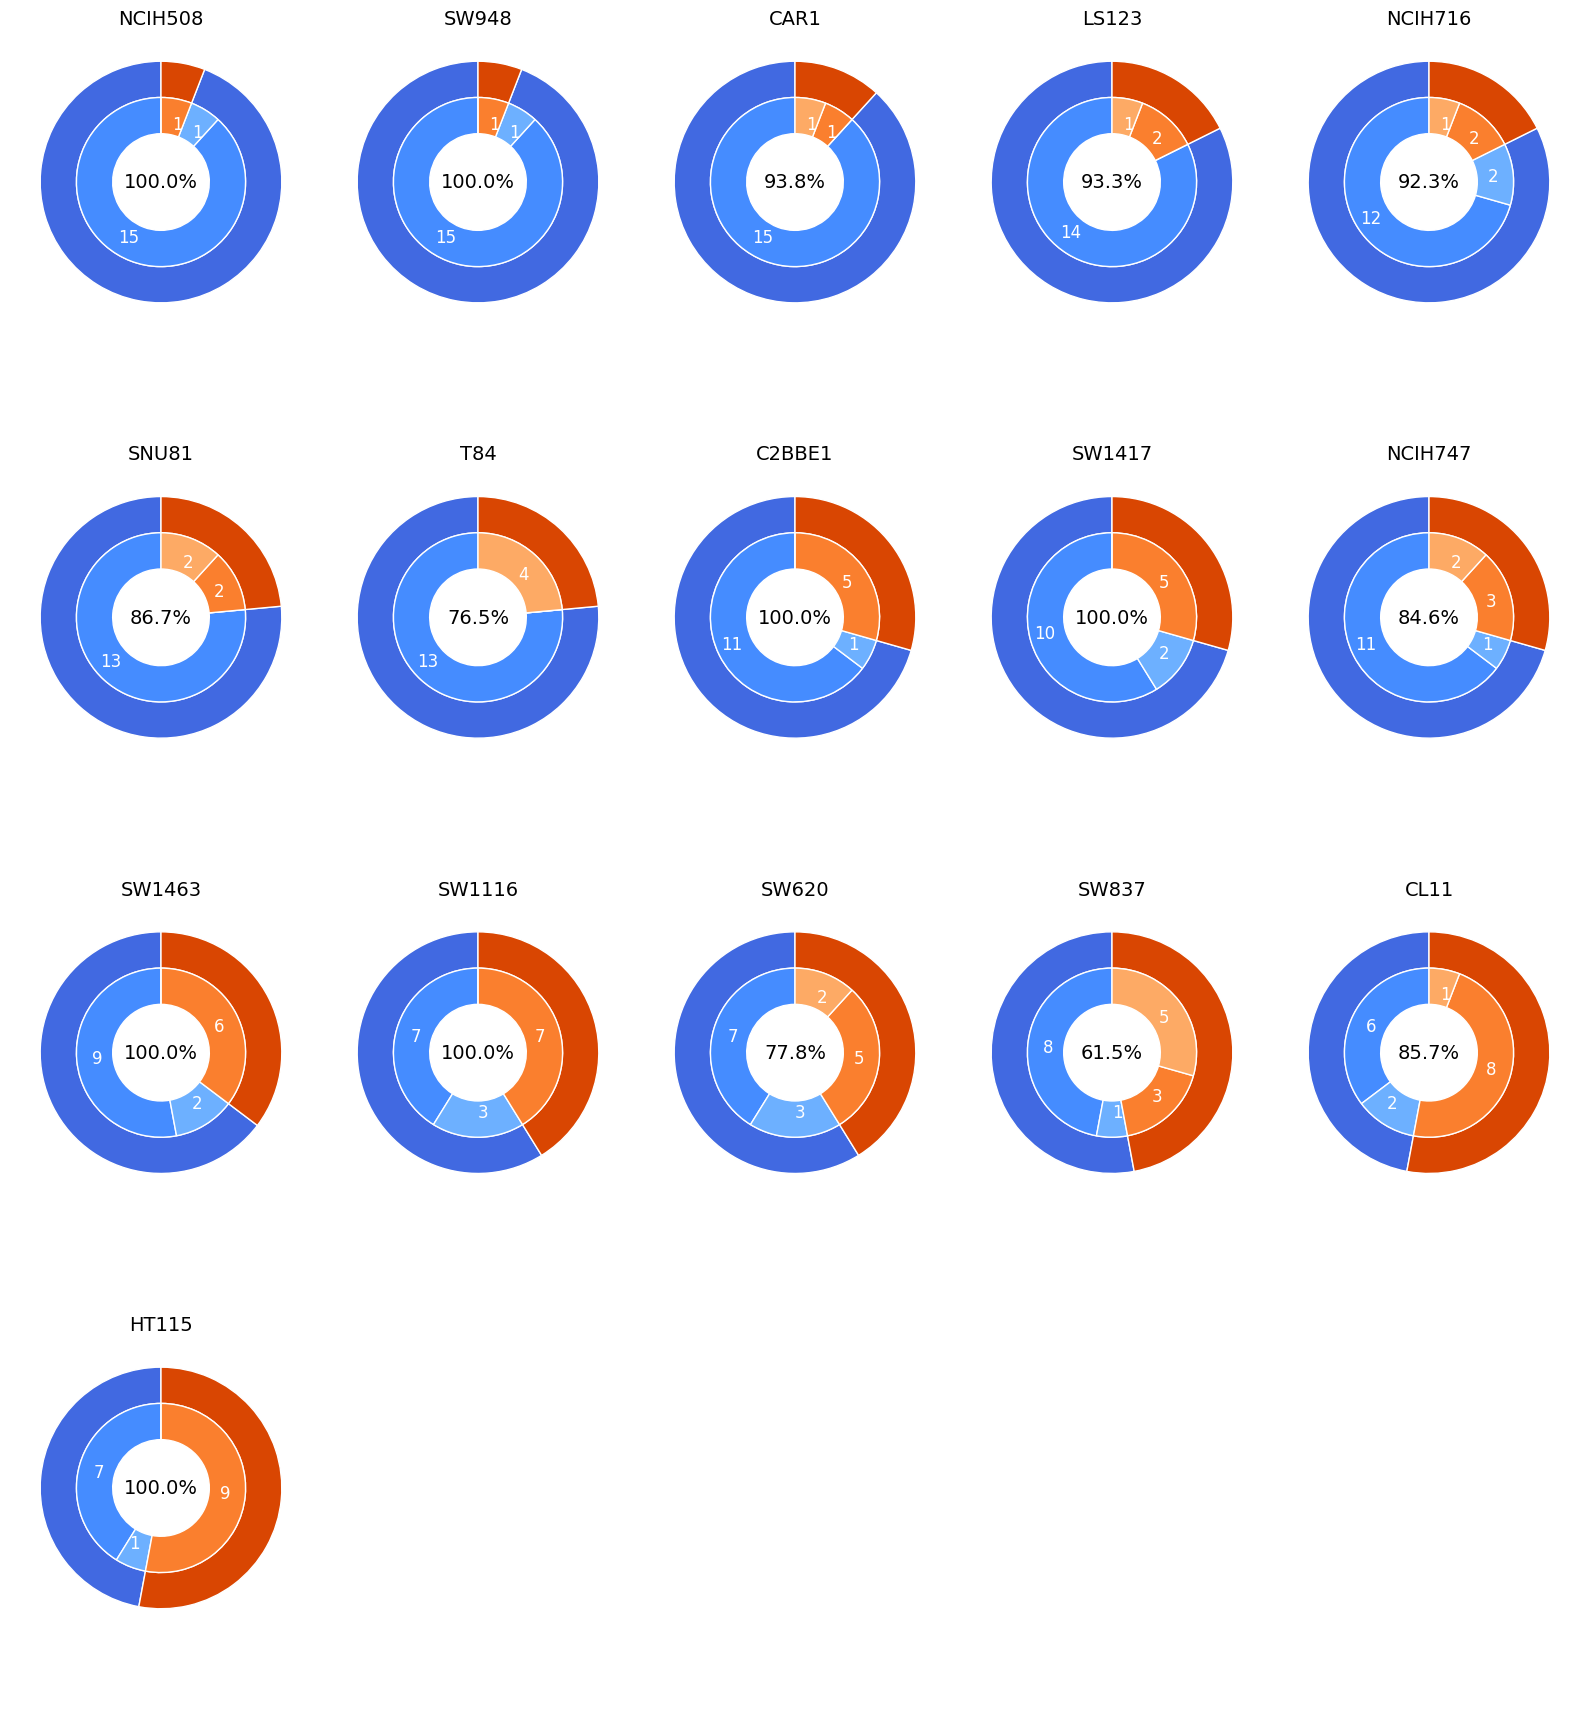

In [11]:
# Grid of rings, one per cell line
make_ring_plots(
    str(results_dir), 
    plots_dir=str(plots_dir), 
    show=show,
    analysis_type="cell_line",
    size=(16, 18),
    ncols=5
)

### Performance by Inhibitor Combination

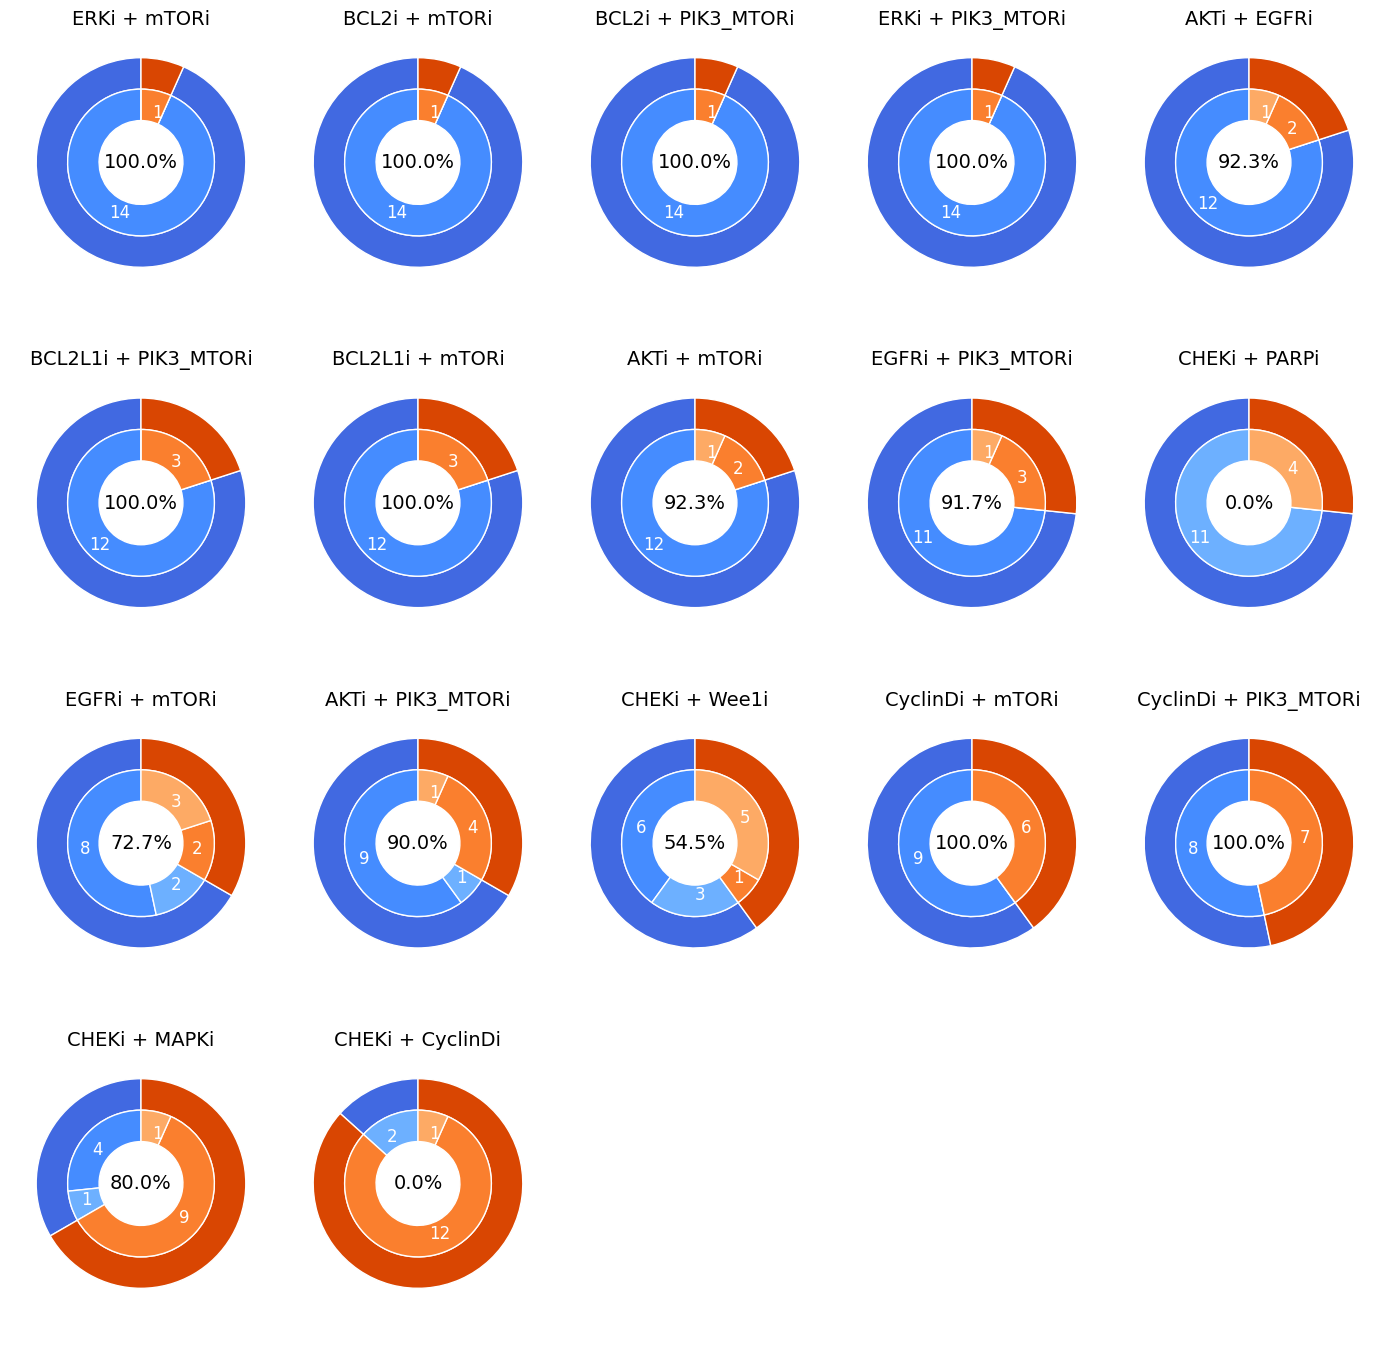

In [12]:
# Grid of rings, one per inhibitor combination
make_ring_plots(
    str(results_dir), 
    plots_dir=str(plots_dir), 
    show=show,
    analysis_type="inhibitor_combination",
    size=(14, 14),
    ncols=5
)

## 2. Classification Performance

Detailed classification metrics including:
- Confusion matrices
- Precision, Recall, F1-Score
- Per-cell-line and per-combination analysis

### Classification by Inhibitor Combination

In [13]:
make_classification_plots(
    str(results_dir), 
    plots_dir=str(plots_dir), 
    show=show,
    analysis_type="combination",
    debug=False
)

{'classification_metrics_df': None,
 'combi_match_df':                        Accuracy  Recall  Precision
 combination                                       
 ERKi + mTORi              93.33  100.00      93.33
 CHEKi + CyclinDi          13.33    0.00       0.00
 AKTi + EGFRi              80.00   92.31      85.71
 CHEKi + MAPKi             33.33   80.00      30.77
 AKTi + mTORi              80.00   92.31      85.71
 BCL2L1i + PIK3_MTORi      80.00  100.00      80.00
 BCL2i + mTORi             93.33  100.00      93.33
 CyclinDi + PIK3_MTORi     53.33  100.00      53.33
 EGFRi + PIK3_MTORi        73.33   91.67      78.57
 BCL2i + PIK3_MTORi        93.33  100.00      93.33
 BCL2L1i + mTORi           80.00  100.00      80.00
 CHEKi + Wee1i             60.00   54.55      85.71
 AKTi + PIK3_MTORi         66.67   90.00      69.23
 ERKi + PIK3_MTORi         93.33  100.00      93.33
 CHEKi + PARPi             73.33    0.00       0.00
 EGFRi + mTORi             66.67   72.73      80.00
 CyclinDi 

### Classification by Cell Line

In [14]:
make_classification_plots(
    str(results_dir), 
    plots_dir=str(plots_dir), 
    show=show,
    analysis_type="cell_line",
    debug=False
)

{'classification_metrics_df':            True Positive  True Negative  False Positive  False Negative  \
 cell_line                                                                 
 SNU81                 13              0               2               2   
 CAR1                  15              0               1               1   
 T84                   13              0               0               4   
 NCIH508               15              1               1               0   
 SW1116                 7              3               7               0   
 LS123                 14              0               2               1   
 SW1463                 9              2               6               0   
 C2BBE1                11              1               5               0   
 CL11                   6              2               8               1   
 SW1417                10              2               5               0   
 SW837                  8              1               3   

## 3. ROC and PR Curves (with New Features)

ROC (Receiver Operating Characteristic) and PR (Precision-Recall) curves assess model discrimination ability.

**New features**:
- **Enhanced hover**: Shows threshold, MCC, balanced accuracy, N pos/neg, confidence intervals
- **Threshold sweeps**: Micro-sensitivity analysis around the configured threshold
- **Bootstrap CIs**: Confidence intervals for AUC scores (if enabled in config)

**Interpretation**:
- **ROC-AUC > 0.7**: Good discrimination
- **PR-AUC**: Better for imbalanced datasets
- Curves closer to top-left = better performance

In [15]:
# Generate ROC and PR curves with all enhancements
make_roc_plots(
    results_dir=str(results_dir),
    plots_dir=str(plots_dir),
    show=show,
    tissue='oncologics',
    width=900,
    height=900,
    plot_sweeps=True  # Enable threshold sweep visualization
)

### Inspect ROC Metrics DataFrame

View detailed metrics including new fields:
- Balanced Accuracy
- Confidence interval bounds
- Sample counts (N positive/negative)

In [16]:
# Load and display ROC metrics
roc_metrics_path = results_dir / 'roc_metrics_df.csv'

if roc_metrics_path.exists():
    roc_metrics_df = pd.read_csv(roc_metrics_path)
    
    print(f"\nROC Metrics Summary ({len(roc_metrics_df)} cell lines):")
    print("=" * 80)
    
    # Display key columns
    display_cols = ['cell_line', 'roc_auc', 'pr_auc', 'mcc', 'balanced_accuracy', 
                    'f1_score', 'n_positive', 'n_negative']
    available_cols = [col for col in display_cols if col in roc_metrics_df.columns]
    
    display(roc_metrics_df[available_cols].round(3))
    
    # Summary statistics
    print("\nSummary Statistics:")
    print(f"  Mean ROC-AUC: {roc_metrics_df['roc_auc'].mean():.3f}")
    print(f"  Mean PR-AUC: {roc_metrics_df['pr_auc'].mean():.3f}")
    if 'mcc' in roc_metrics_df.columns:
        print(f"  Mean MCC: {roc_metrics_df['mcc'].mean():.3f}")
    if 'balanced_accuracy' in roc_metrics_df.columns:
        print(f"  Mean Balanced Accuracy: {roc_metrics_df['balanced_accuracy'].mean():.3f}")
else:
    print(f"ROC metrics file not found at {roc_metrics_path}")


ROC Metrics Summary (16 cell lines):


,cell_line,roc_auc,pr_auc,balanced_accuracy,f1_score,n_positive,n_negative
0,C2BBE1,0.647,0.898,0.5,0.884,19.0,5.0
1,CAR1,NaN,NaN,NaN,NaN,NaN,NaN
2,CL11,0.668,0.636,0.5,0.629,11.0,13.0
3,HT115,0.496,0.750,0.5,0.800,16.0,8.0
4,LS123,0.746,0.964,0.5,0.933,21.0,3.0
5,NCIH508,NaN,NaN,NaN,NaN,NaN,NaN
6,NCIH716,0.625,0.962,0.5,0.957,22.0,2.0
7,NCIH747,0.130,0.936,0.5,0.979,23.0,1.0
8,SNU81,0.579,0.806,0.5,0.857,18.0,6.0
9,SW1116,0.601,0.678,0.5,0.703,13.0,11.0



Summary Statistics:
  Mean ROC-AUC: 0.571
  Mean PR-AUC: 0.822
  Mean Balanced Accuracy: 0.500


## 4. Prediction Distributions

Analyze distribution of predicted synergy scores by mechanism/family.

In [17]:
make_pred_distribution_plots(
    str(results_dir), 
    plots_dir=str(plots_dir), 
    show=show,
    family_priority=['MAPK', 'RTK', 'PI3K']
)

## 5. Experimental Distributions

Analyze distribution of experimental synergy observations.

In [18]:
make_experimental_distribution_plots(
    str(results_dir), 
    plots_dir=str(plots_dir), 
    show=show,
    selected_mechanism=('RTK', 'MAPK', 'PI3K'),
    threshold=0,
    stackedbar_size=(800, 1200),
    distribution_size=(1400, 1000)
)

## 6. Profile Categories

Visualize drug profile categories and their performance.

In [19]:
make_profilecat_plots(
    str(results_dir), 
    plots_dir=str(plots_dir), 
    show=show
)

## Summary

All plots have been generated and saved to the plots directory.

**Key files generated**:
- `ROC_curve_oncologics.html` / `.svg` - ROC curves with enhanced hover
- `PR_curve_oncologics.html` / `.svg` - PR curves with enhanced hover
- `threshold_sweep_*.html` / `.svg` - Threshold sensitivity plots
- Various ring plots, classification plots, and distribution visualizations

**New metrics available in `roc_metrics_df.csv`**:
- `mcc`: Matthews Correlation Coefficient (robust to class imbalance)
- `balanced_accuracy`: Average of TPR and TNR
- `roc_auc_ci_low` / `roc_auc_ci_high`: Bootstrap confidence intervals (if enabled)
- `pr_auc_ci_low` / `pr_auc_ci_high`: Bootstrap confidence intervals (if enabled)
- `threshold`: Binary classification threshold used
- `n_positive` / `n_negative`: Sample counts per class